# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import numpy.ma as ma
import matplotlib.cm as cm
import astropy.coordinates as coord
import astropy.units as u
import os
import seaborn as sns

In [2]:
from astropy.io import fits
from astropy.table import Table, Column, vstack
from scipy.optimize import curve_fit
from statistics import mean
from scipy.stats import chi2
from scipy.stats import chisquare
from astropy.io import ascii
from gammapy.estimators import FluxPoints, FluxPointsEstimator
from gammapy.datasets import Datasets, FluxPointsDataset
from gammapy.modeling import Fit
from gammapy.modeling.models import (ExpCutoffPowerLawSpectralModel, LogParabolaSpectralModel, PowerLawSpectralModel, SkyModel)
from collections import Counter
from rapidfuzz import fuzz
from sklearn.metrics import r2_score

# Set Paths

In [3]:
catalog_dir = "/home/alab_student/Tim/Projects/Catalogs/"
outdir = "/home/alab_student/Tim/Projects/MeV_Blazars/Outputs/"

# Define Functions

In [4]:
def mask_catalog_by_class(catalog, class_column):
    fsrq_mask = [x in ['FSRQ','fsrq'] for x in catalog[class_column].tolist()]
    bll_mask = [x in ['BLL','bll'] for x in catalog[class_column].tolist()]
    bcu_mask = [x in ['BCU','bcu'] for x in catalog[class_column].tolist()]

    fsrq_masked_catalog = catalog[fsrq_mask]
    bll_masked_catalog = catalog[bll_mask]
    bcu_masked_catalog = catalog[bcu_mask]

    return fsrq_masked_catalog, bll_masked_catalog, bcu_masked_catalog

def line(x_data,m,c): 
    return m*x_data + c

def sigma_difference(x1, err1, x2, err2):
    return abs(x1 - x2) / np.sqrt(err1**2 + err2**2)

# Catalogs

In [5]:
Fermi_AGN_Cat_lo = Table.read(catalog_dir + "table-4LAC-DR3-l.fits")
Fermi_AGN_Cat_hi = Table.read(catalog_dir + "table-4LAC-DR3-h.fits")
Fermi_LAC_DR3 = vstack([Fermi_AGN_Cat_lo, Fermi_AGN_Cat_hi])
#Fermi_LAC_DR3.pprint_all()

# Code

In [6]:
AGN_catalog_IC_peak = Fermi_LAC_DR3['HE_EPeak'].tolist()
print(AGN_catalog_IC_peak)

MeV_gap_Fermi_AGN_catalog_IC_peaks = Fermi_LAC_DR3[Fermi_LAC_DR3['HE_EPeak'] <= 100]
#MeV_gap_Fermi_AGN_catalog_IC_peaks

print(Counter(MeV_gap_Fermi_AGN_catalog_IC_peaks['CLASS'].tolist()))

[None, 30467.08984375, 5067.017578125, None, 210.99874877929688, 52.74098205566406, 98809.25, 417.94268798828125, 118.9495620727539, 1807.4232177734375, None, 1698.9822998046875, 196.00172424316406, 22241.693359375, 140.0635986328125, 5588.93505859375, 4336.5517578125, None, 239.01734924316406, 27088.67578125, 382.5682067871094, 1066.364013671875, 19852.21484375, 18998.673828125, 268.50469970703125, None, 2617.74365234375, 736.1133422851562, None, 4187.1826171875, 8160.97265625, 236.68125915527344, 1616.490966796875, 141.26910400390625, 6354.3955078125, 869.6210327148438, 33.24269104003906, 149.6060791015625, 777.0947875976562, 227.70437622070312, 2128.4560546875, 3209.771240234375, 162.97328186035156, 138.2258758544922, 331.18670654296875, 2260.6337890625, 6918.89306640625, 117.9891357421875, 23095.533203125, 423.49615478515625, 2476.2958984375, 101.71955108642578, 143.0712432861328, 92.99160766601562, 558.8300170898438, 1202.0064697265625, 142.74224853515625, 20876.8984375, 5833.6035

In [7]:
FSRQ_mask = [str(val).lower() == 'fsrq' for val in Fermi_LAC_DR3['CLASS']]
Fermi_LAC_DR3_fsrq = Fermi_LAC_DR3[FSRQ_mask]
HE_mask = [val != None for val in Fermi_LAC_DR3_fsrq['HE_EPeak'].tolist()]
Fermi_LAC_DR3_FSRQ = Fermi_LAC_DR3_fsrq[HE_mask]
Fermi_LAC_DR3_FSRQ

Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Signif_Avg,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Index,Unc_PL_Index,Pivot_Energy,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,Flags,CLASS,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Counterpart_Catalog,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,VLBI_Counterpart,Redshift,SED_class,HE_EPeak,Unc_HE_EPeak,HE_nuFnuPeak,Unc_HE_nuFnuPeak,nu_syn,nuFnu_syn,Variability_Index,Frac_Variability,Unc_Frac_Variability,Highest_energy
,,deg,deg,deg,deg,,ph / (s cm2),ph / (s cm2),erg / (s cm2),erg / (s cm2),,,,MeV,,,,,,,,,,,deg,deg,deg,,,,MeV,MeV,MeV / (s cm2),MeV / (s cm2),Hz,erg / (s cm2),,,,GeV
bytes18,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float32,int16,bytes5,bytes30,float32,float32,bytes20,float64,float64,float64,bytes20,float32,bytes6,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
4FGL J0102.8+5824,1,15.7010,58.4092,124.4245,-4.4296,54.230,4.0241e-09,1.1221e-10,4.0597e-11,1.5438e-12,LogParabola,2.2844,0.0187,1611.06,2.2754,0.0244,0.0654,0.0132,0,fsrq,TXS 0059+581,1.0000,0.9938,bzcat,15.6907,58.4031,0.00000,RFC J0102+5824,0.644,LSP,196.00172,94.79877,6.259146e-06,4.8552357e-07,4518559400000.0,2.2106908e-11,955.4202,0.8770,0.1885,55.018
4FGL J0109.7+6133,1,17.4450,61.5615,125.1143,-1.2325,35.328,2.1161e-09,8.7936e-11,2.8608e-11,1.5612e-12,LogParabola,2.6061,0.0270,938.71,2.6031,0.0402,0.1585,0.0280,0,fsrq,TXS 0106+612,1.0000,0.9835,bzcat,17.4431,61.5585,0.00000,RFC J0109+6133,0.783,LSP,140.0636,51.690033,6.974812e-06,8.451121e-07,15135613000000.0,2.7560812e-12,1024.9794,1.0871,0.2340,-inf
4FGL J0228.7+6718,1,37.1976,67.3064,132.1348,6.1906,13.716,7.5172e-10,6.6859e-11,8.4558e-12,1.1478e-12,LogParabola,2.5508,0.0604,1425.20,2.5927,0.0954,0.1651,0.0586,0,fsrq,4C +67.05,0.9980,0.9736,qso,37.2085,67.3508,0.00000,RFC J0228+6721,0.523,LSP,236.68126,156.16183,1.7549216e-06,3.7784957e-07,7943282500000.0,5.236559e-12,44.1520,0.5054,0.1418,-inf
4FGL J0253.9+5103,1,43.4933,51.0633,141.7660,-7.2721,15.282,7.0014e-10,5.5774e-11,1.0111e-11,8.3386e-13,PowerLaw,2.4833,0.0555,1166.85,2.4716,0.0688,0.0663,0.0395,0,fsrq,TXS 0250+508,0.9999,0.9755,bzcat,43.4900,51.0490,0.00000,RFC J0253+5102,1.732,LSP,33.24269,74.2533,2.4444284e-06,1.3358957e-06,3548134000000.0,2.696094e-13,122.7182,0.7706,0.1784,21.688
4FGL J0347.0+4844,1,56.7527,48.7376,150.2369,-4.6011,5.346,2.7568e-10,5.2587e-11,4.9797e-12,1.0311e-12,PowerLaw,2.6538,0.1274,1013.82,2.6224,0.1914,0.1447,0.1184,8,fsrq,IVS B0343+485,0.9997,0.0000,bzcat,56.7984,48.7104,0.00000,RFC J0347+4842,2.043,LSP,117.989136,234.87428,1.0623924e-06,7.359727e-07,5308844300000.0,2.8310726e-12,26.9997,0.5664,0.2368,-inf
4FGL J0358.9+6004,1,59.7328,60.0767,144.3774,5.2614,8.341,4.0602e-10,5.5605e-11,5.2539e-12,9.6045e-13,LogParabola,2.5826,0.0886,1458.45,2.6898,0.1531,0.1486,0.0834,0,fsrq,TXS 0354+599,0.9908,0.9761,rfc,59.7610,60.0895,0.00000,RFC J0359+6005,0.455,LSP,143.07124,166.12883,1.2355454e-06,4.6899368e-07,7516229000000.0,5.4622175e-12,131.6600,1.3926,0.3213,-inf
4FGL J0359.6+5057,1,59.9158,50.9590,150.4005,-1.5903,32.235,2.4510e-09,1.0890e-10,3.6800e-11,1.8943e-12,LogParabola,2.6383,0.0267,956.41,2.6756,0.0392,0.1449,0.0265,0,fsrq,NRAO 150,0.9999,0.9937,bzcat,59.8739,50.9639,0.00000,RFC J0359+5057,1.52,LSP,92.99161,40.179634,1.0187587e-05,1.4836091e-06,3491403100000.0,1.37332715e-11,948.9951,0.9482,0.2044,-inf
4FGL J0533.3+4823,1,83.3338,48.3834,162.1653,8.2412,59.807,3.1582e-09,9.2555e-11,3.3952e-11,1.0671e-12,LogParabola,2.3663,0.0190,728.45,2.2810,0.0287,0.0890,0.0152,0,fsrq,TXS 0529+483,0.9999,0.9826,bzcat,83.3161,48.3813,0.00000,RFC J0533+4822,1.16,LSP,150.34402,56.71124,6.311565e-06,4.4675357e-07,9332543000000.0,6.678732e-12,279.1035,0.3550,0.0790,108.379


In [8]:
Fermi_LAC_DR3_FSRQ_IC_peaks = Fermi_LAC_DR3_FSRQ['HE_EPeak'].tolist()
#print(len(Fermi_LAC_DR3_FSRQ_IC_peaks))

Fermi_LAC_DR3_FSRQ_IC_peaks_unc = Fermi_LAC_DR3_FSRQ['Unc_HE_EPeak'].tolist()
#print(len(Fermi_LAC_DR3_FSRQ_IC_peaks_unc))

Relative_unc = [(a / b) * 100 for a, b in zip(Fermi_LAC_DR3_FSRQ_IC_peaks_unc, Fermi_LAC_DR3_FSRQ_IC_peaks)]
#print(Relative_unc)

percent_above_50 = sum(x > 50 for x in Relative_unc) / len(Relative_unc) * 100
print(f"Percentage of FSRQ IC peaks with uncertainty > 50%: {percent_above_50}%")

Relative_unc_mask = []
for i in Relative_unc:
    if i >= 50:
        mask = False
        Relative_unc_mask.append(mask)
    else:
        mask = True
        Relative_unc_mask.append(mask)

#print(Relative_unc_mask)

Fermi_LAC_DR3_FSRQ[Relative_unc_mask]

Percentage of FSRQ IC peaks with uncertainty > 50%: 65.24216524216524%


Source_Name,DataRelease,RAJ2000,DEJ2000,GLON,GLAT,Signif_Avg,Flux1000,Unc_Flux1000,Energy_Flux100,Unc_Energy_Flux100,SpectrumType,PL_Index,Unc_PL_Index,Pivot_Energy,LP_Index,Unc_LP_Index,LP_beta,Unc_LP_beta,Flags,CLASS,ASSOC1,ASSOC_PROB_BAY,ASSOC_PROB_LR,Counterpart_Catalog,RA_Counterpart,DEC_Counterpart,Unc_Counterpart,VLBI_Counterpart,Redshift,SED_class,HE_EPeak,Unc_HE_EPeak,HE_nuFnuPeak,Unc_HE_nuFnuPeak,nu_syn,nuFnu_syn,Variability_Index,Frac_Variability,Unc_Frac_Variability,Highest_energy
,,deg,deg,deg,deg,,ph / (s cm2),ph / (s cm2),erg / (s cm2),erg / (s cm2),,,,MeV,,,,,,,,,,,deg,deg,deg,,,,MeV,MeV,MeV / (s cm2),MeV / (s cm2),Hz,erg / (s cm2),,,,GeV
bytes18,int16,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float32,int16,bytes5,bytes30,float32,float32,bytes20,float64,float64,float64,bytes20,float32,bytes6,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32
4FGL J0102.8+5824,1,15.7010,58.4092,124.4245,-4.4296,54.230,4.0241e-09,1.1221e-10,4.0597e-11,1.5438e-12,LogParabola,2.2844,0.0187,1611.06,2.2754,0.0244,0.0654,0.0132,0,fsrq,TXS 0059+581,1.0000,0.9938,bzcat,15.6907,58.4031,0.00000,RFC J0102+5824,0.644,LSP,196.00172,94.79877,6.259146e-06,4.8552357e-07,4518559400000.0,2.2106908e-11,955.4202,0.8770,0.1885,55.018
4FGL J0109.7+6133,1,17.4450,61.5615,125.1143,-1.2325,35.328,2.1161e-09,8.7936e-11,2.8608e-11,1.5612e-12,LogParabola,2.6061,0.0270,938.71,2.6031,0.0402,0.1585,0.0280,0,fsrq,TXS 0106+612,1.0000,0.9835,bzcat,17.4431,61.5585,0.00000,RFC J0109+6133,0.783,LSP,140.0636,51.690033,6.974812e-06,8.451121e-07,15135613000000.0,2.7560812e-12,1024.9794,1.0871,0.2340,-inf
4FGL J0359.6+5057,1,59.9158,50.9590,150.4005,-1.5903,32.235,2.4510e-09,1.0890e-10,3.6800e-11,1.8943e-12,LogParabola,2.6383,0.0267,956.41,2.6756,0.0392,0.1449,0.0265,0,fsrq,NRAO 150,0.9999,0.9937,bzcat,59.8739,50.9639,0.00000,RFC J0359+5057,1.52,LSP,92.99161,40.179634,1.0187587e-05,1.4836091e-06,3491403100000.0,1.37332715e-11,948.9951,0.9482,0.2044,-inf
4FGL J0533.3+4823,1,83.3338,48.3834,162.1653,8.2412,59.807,3.1582e-09,9.2555e-11,3.3952e-11,1.0671e-12,LogParabola,2.3663,0.0190,728.45,2.2810,0.0287,0.0890,0.0152,0,fsrq,TXS 0529+483,0.9999,0.9826,bzcat,83.3161,48.3813,0.00000,RFC J0533+4822,1.16,LSP,150.34402,56.71124,6.311565e-06,4.4675357e-07,9332543000000.0,6.678732e-12,279.1035,0.3550,0.0790,108.379
4FGL J0555.6+3947,1,88.9015,39.7878,171.6787,7.2873,22.446,8.0544e-10,6.3572e-11,1.4899e-11,9.8495e-13,LogParabola,2.7188,0.0384,492.37,2.5878,0.0728,0.2706,0.0532,0,fsrq,B2 0552+39A,0.9993,0.9843,bzcat,88.8784,39.8137,0.00000,RFC J0555+3948,2.365,LSP,166.1943,48.170452,4.227509e-06,4.875281e-07,342767800000.0,1.7476039e-12,207.9144,0.6921,0.1548,-inf
4FGL J0601.4+2320,1,90.3703,23.3478,186.6205,0.2296,7.342,4.2247e-10,9.1434e-11,8.5334e-12,1.7149e-12,LogParabola,2.8369,0.0970,670.81,2.8448,0.1886,0.3699,0.1388,4,fsrq,MG2 J060149+2324,0.9829,0.0000,bzcat,90.4473,23.4149,0.00000,RFC J0601+2324,0.274,LSP,214.10828,100.175,2.4578378e-06,6.671236e-07,17782794000000.0,2.042829e-12,10.4873,0.0000,10.0000,-inf
4FGL J0641.7-0320,1,100.4371,-3.3466,214.8105,-3.6792,20.060,1.3068e-09,9.9439e-11,2.0891e-11,1.5696e-12,LogParabola,2.6810,0.0407,539.55,2.5440,0.0706,0.2099,0.0492,0,FSRQ,PMN J0641-0320,1.0000,0.9780,identified,100.4631,-3.3468,0.00000,RFC J0641-0320,1.196,LSP,147.6876,62.22365,5.6209333e-06,8.589968e-07,5888436300000.0,7.0327793e-13,375.4046,1.0221,0.2239,-inf
4FGL J0643.3+0857,1,100.8345,8.9525,204.0421,2.2863,27.195,2.1367e-09,1.1351e-10,2.6828e-11,1.6021e-12,LogParabola,2.5390,0.0310,950.76,2.5705,0.0488,0.1825,0.0338,0,fsrq,PMN J0643+0857,0.9952,0.9613,wise,100.8602,8.9606,0.00000,RFC J0643+0857,0.882,LSP,199.21071,62.00035,6.1034934e-06,6.1037355e-07,5888436300000.0,3.918817e-12,394.8587,0.8475,0.1857,22.493


[2.2922598918972814, 2.1463252804176234, 1.9684437559861852, 2.1770861719806747, 2.220616138779774, 2.3306334552959718, 2.1693440530696373, 2.2993126803164734, 2.2781426680505756, 2.351053611223471, 2.330126124193714, 2.56304860671103, 2.246305992515574, 2.6407570974636525, 2.6823362335495586, 2.4437527367903282, 2.288469328588769, 2.703435595502024, 2.3862784967986053, 2.155060868270381, 2.5333107520531306, 2.604627102937136, 1.904426832456697, 1.8174331965769734, 2.625647964436753, 2.2846447356114967, 2.43249023377146, 3.659408867500646, 2.4133865435665056, 1.9755673739418078, 2.1879659517272403, 2.050074904643522, 2.710611059315904, 3.3725874152180335, 2.188071515282558, 2.286551016533597, 2.438130204835219, 2.849642099924288, 2.23756886406262, 2.501404596892848, 1.8856282552256627, 2.7306992971487607, 2.2783676795603904, 2.1655932008618026, 2.0453520223383594, 2.4414088302951886, 1.927629592806098, 2.121211544193248, 2.376864849319971, 2.103575479645212, 3.5842321146698923, 2.85651

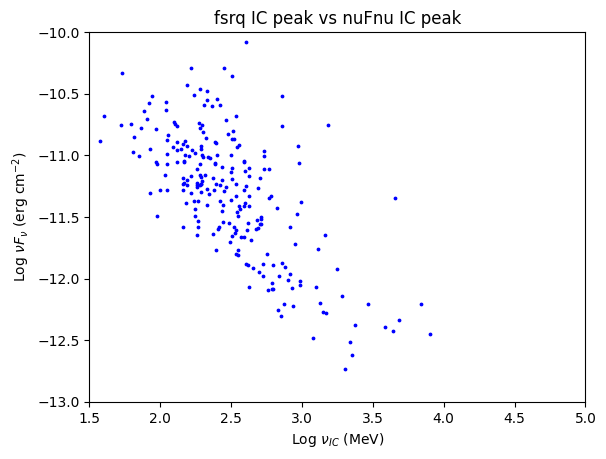

In [9]:
low_unc_FSRQ_IC_peaks = Fermi_LAC_DR3_FSRQ[Relative_unc_mask]['HE_EPeak'].tolist()
low_unc_FSRQ_IC_peaks = [np.log10(i) for i in low_unc_FSRQ_IC_peaks]
print(low_unc_FSRQ_IC_peaks)
print(len(low_unc_FSRQ_IC_peaks))

low_unc_nuFnu_FSRQ_IC_peaks =  Fermi_LAC_DR3_FSRQ[Relative_unc_mask]['HE_nuFnuPeak'].tolist()
low_unc_nuFnu_FSRQ_IC_peaks = [np.log10(i * 1.60218e-6) for i in low_unc_nuFnu_FSRQ_IC_peaks]
print(low_unc_nuFnu_FSRQ_IC_peaks)
print(len(low_unc_nuFnu_FSRQ_IC_peaks))

plt.scatter(low_unc_FSRQ_IC_peaks, low_unc_nuFnu_FSRQ_IC_peaks, s=3, color='blue')
plt.xlim(1.5,5)
plt.ylim(-13,-10)
plt.xlabel(r'Log $\nu_{IC}$ (MeV)')
plt.ylabel(r'Log $\nu F_{\nu}$ (erg cm$^{-2}$)')
plt.title('fsrq IC peak vs nuFnu IC peak')
plt.savefig(outdir + 'Fermi_LAC_DR3_FSRQ_IC_peaks_points.png')

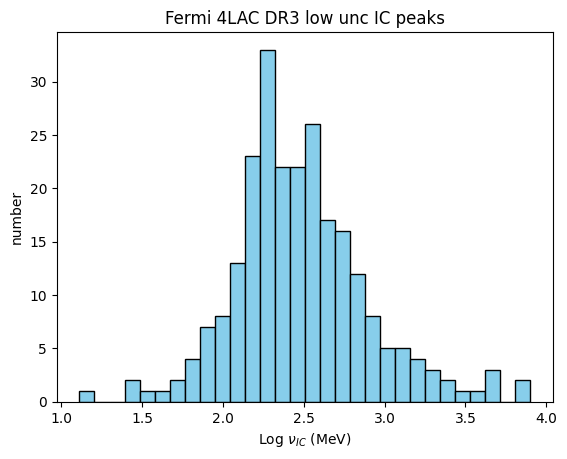

In [10]:
num_bins = 30
fig, ax = plt.subplots()
n, bins, patches = ax.hist(low_unc_FSRQ_IC_peaks, num_bins, label ='IC peak energy', color = 'skyblue', edgecolor = 'black')
plt.title('Fermi 4LAC DR3 low unc IC peaks')
plt.xlabel(r'Log $\nu_{IC}$ (MeV)')
plt.ylabel('number')
plt.savefig(outdir + 'Fermi_4LAC_fsrq_low_unc_IC_peaks.png')

Text(0.5, 1.0, 'Fermi 4LAC DR3 low unc FSRQ IC peaks')

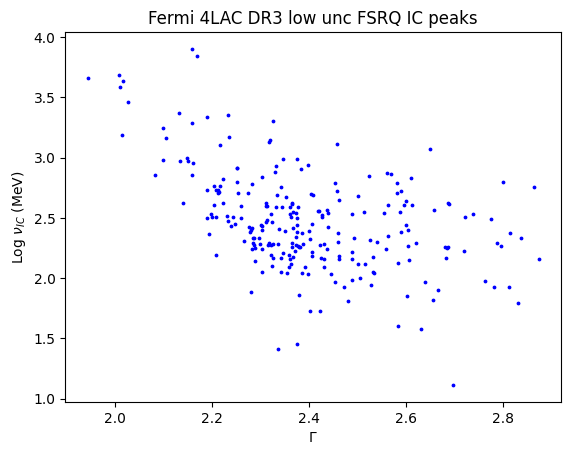

In [11]:
low_unc_FSRQ_PL_index = Fermi_LAC_DR3_FSRQ[Relative_unc_mask]['PL_Index'].tolist()

plt.scatter(low_unc_FSRQ_PL_index, low_unc_FSRQ_IC_peaks, s=3, color='blue')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'Log $\nu_{IC}$ (MeV)')
plt.title('Fermi 4LAC DR3 low unc FSRQ IC peaks')

[2.2922598918972814, 2.1463252804176234, 2.3741638710779016, 1.5216961732508882, 2.0718420199803833, 2.155552351179956, 1.9684437559861852, 2.1770861719806747, 2.212782633575238, 2.220616138779774, 2.3306334552959718, 2.1693440530696373, 2.2993126803164734, 2.2781426680505756, 2.351053611223471, -0.336070545139078, 2.196853666108285, 2.1007602999649797, 2.330126124193714, 2.053275326467774, 2.56304860671103, 2.246305992515574, 2.6407570974636525, 2.4351655401704684, 2.1134331453504474, 2.6823362335495586, 2.4437527367903282, 2.288469328588769, 2.703435595502024, 2.3862784967986053, 2.8292729840811024, 2.155060868270381, 2.609219205689564, 2.5333107520531306, 2.604627102937136, 1.904426832456697, 1.8174331965769734, 2.0729592953715192, 1.7221621275608567, 2.082926783087399, 2.10516620821182, 2.41026315217511, 2.2423080701319726, 2.8571370720832547, 1.9021888007796306, 1.7288305884208905, 1.8694428755038919, 2.2323902457611045, 1.7905534614914513, 1.33895331870264, 2.2627255628555973, 1.

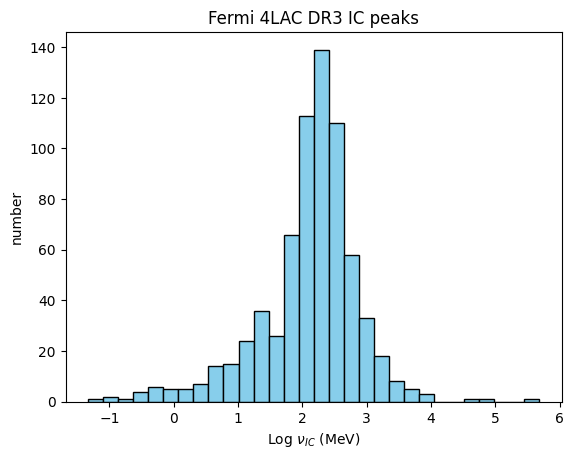

In [12]:
Fermi_LAC_DR3_FSRQ_IC_peaks = [np.log10(i) for i in Fermi_LAC_DR3_FSRQ_IC_peaks]
print(Fermi_LAC_DR3_FSRQ_IC_peaks)
print(len(Fermi_LAC_DR3_FSRQ_IC_peaks))


num_bins = 30
fig, ax = plt.subplots()
n, bins, patches = ax.hist(Fermi_LAC_DR3_FSRQ_IC_peaks, num_bins, label ='IC peak energy', color = 'skyblue', edgecolor = 'black')
plt.title('Fermi 4LAC DR3 IC peaks')
plt.xlabel(r'Log $\nu_{IC}$ (MeV)')
plt.ylabel('number')
plt.savefig(outdir + 'Fermi_4LAC_fsrq_IC_peaks.png')

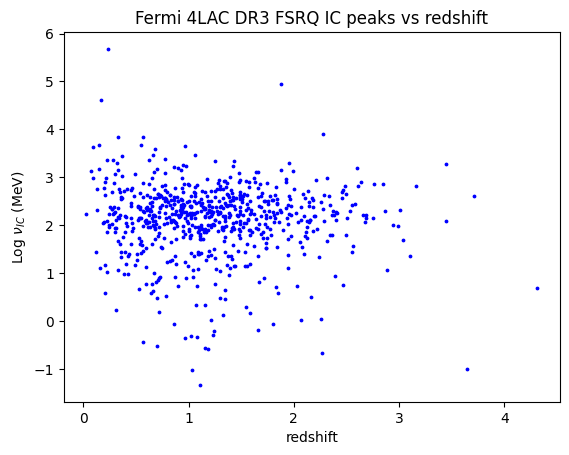

In [13]:
Fermi_LAC_DR3_FSRQ_redshift = Fermi_LAC_DR3_FSRQ['Redshift'].tolist()

plt.scatter(Fermi_LAC_DR3_FSRQ_redshift, Fermi_LAC_DR3_FSRQ_IC_peaks, s =3, color='blue')
plt.title('Fermi 4LAC DR3 FSRQ IC peaks vs redshift')
plt.xlabel('redshift')
plt.ylabel(r'Log $\nu_{IC}$ (MeV)')
plt.savefig(outdir + 'Fermi_4LAC_fsrq_IC_peaks_redshift.png')

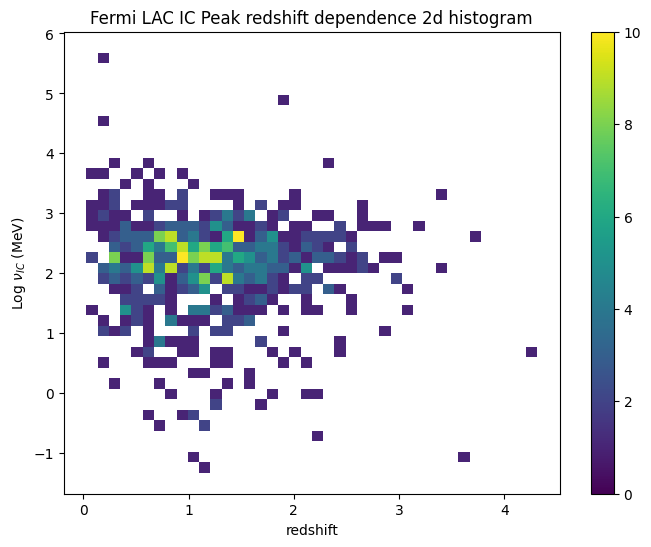

In [14]:
plt.figure(figsize=(8, 6))
sns.histplot(x=Fermi_LAC_DR3_FSRQ_redshift, y=Fermi_LAC_DR3_FSRQ_IC_peaks, bins=40, cmap="viridis",cbar=True)
plt.xlabel('redshift')
plt.ylabel(r'Log $\nu_{IC}$ (MeV)')
#plt.xlim(0,4)
#plt.ylim(-0.5,2.5)
plt.title('Fermi LAC IC Peak redshift dependence 2d histogram')
plt.savefig(outdir + 'Fermi_LAC_IC_Peak_z_2d_hist.png')

[2.2844250202178955, 2.60606050491333, 2.5507659912109375, 2.483255624771118, 2.653798818588257, 2.5826351642608643, 2.6383066177368164, 2.3662593364715576, 2.555142402648926, 2.7187740802764893, 2.836869716644287, 2.6810357570648193, 2.539001703262329, 2.4228334426879883, 2.5627520084381104, 2.589285135269165, 2.3187448978424072, 2.5444343090057373, 2.297461986541748, 2.6008920669555664, 2.657691717147827, 2.684386968612671, 2.598566770553589, 2.37920880317688, 2.5449163913726807, 2.5009751319885254, 2.5995328426361084, 2.7874951362609863, 2.5814590454101562, 2.3743603229522705, 2.3252792358398438, 2.487879991531372, 2.419295072555542, 2.4880220890045166, 2.611253023147583, 2.6645138263702393, 2.654059886932373, 2.587958335876465, 2.4382216930389404, 2.6222498416900635, 2.390063524246216, 2.4249508380889893, 2.353538990020752, 2.259154796600342, 2.724256753921509, 2.730292320251465, 2.535158395767212, 2.7941009998321533, 2.6096160411834717, 2.8279330730438232, 2.445587635040283, 2.468

Text(0, 0.5, 'Log $\\nu_{IC}$ (MeV)')

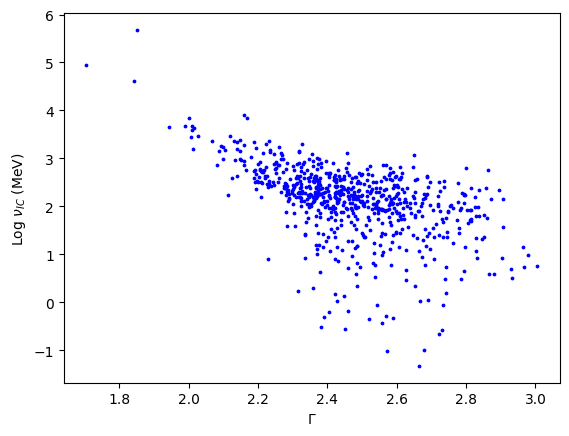

In [15]:
Fermi_LAC_DR3_FSRQ_PL_index = Fermi_LAC_DR3_FSRQ['PL_Index'].tolist()
print(Fermi_LAC_DR3_FSRQ_PL_index)

plt.scatter(Fermi_LAC_DR3_FSRQ_PL_index, Fermi_LAC_DR3_FSRQ_IC_peaks, s=3, color='blue')
plt.xlabel(r'$\Gamma$')
plt.ylabel(r'Log $\nu_{IC}$ (MeV)')

In [16]:
Matched_Blazar_Fit_All = Table.read(outdir + 'Blazar_Fitter_out/Matched_Blazar_Fits_All/MeV_Blazar_Fits_All_results.fits')
Matched_Blazar_Fit_All.pprint_all()

Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU = mask_catalog_by_class(Matched_Blazar_Fit_All, 'Class')
Matched_Blazar_Fit_Catalogs_by_class = [Matched_Blazar_Fit_FSRQ, Matched_Blazar_Fit_BLL, Matched_Blazar_Fit_BCU]

          Name          Class       Alpha              Alpha_Err                Beta                 Beta_Err           IC_Peak_Energy       IC_Peak_Energy_Err   IC_Peak_Energy_Flux            Chi2         
----------------------- ----- ------------------ --------------------- ---------------------- --------------------- ---------------------- --------------------- ---------------------- ----------------------
           1ES 0033+595   bll  2.464397258702322    0.0139830278645407  -0.024742504753178567 0.0009929641080672885                   None                  None                   None   6.59620476171133e-06
        RX J0115.7+2519   bll 2.0701342881999643   0.03375956054851627 -0.0037190492882141135 0.0019780382128528682                   None                  None                   None  8.530994205772787e-06
           1ES 0120+340   bll  2.701283632242646    0.0569648100132727  -0.035524232360088386  0.004013611067589626                   None                  None            

In [17]:
Matched_Blazar_Fit_FSRQ_IC_peak = Matched_Blazar_Fit_FSRQ['IC_Peak_Energy'].tolist()
Matched_Blazar_Fit_FSRQ_names = Matched_Blazar_Fit_FSRQ['Name'].tolist()
Matched_Blazar_Fit_FSRQ_IC_peak_err = Matched_Blazar_Fit_FSRQ['IC_Peak_Energy_Err'].tolist()
zipped_name_peaks_fsrq = list(zip(Matched_Blazar_Fit_FSRQ_names, Matched_Blazar_Fit_FSRQ_IC_peak, Matched_Blazar_Fit_FSRQ_IC_peak_err))
filtered_name_peaks_fsrq = [x for x in zipped_name_peaks_fsrq if x[1] != 'None']
Matched_Blazar_Fit_FSRQ_names, Matched_Blazar_Fit_FSRQ_IC_peak, Matched_Blazar_Fit_FSRQ_IC_peak_err = zip(*filtered_name_peaks_fsrq)
Matched_Blazar_Fit_FSRQ_IC_peak = [float(x) for x in Matched_Blazar_Fit_FSRQ_IC_peak]
Matched_Blazar_Fit_FSRQ_IC_peak_log = [math.log10(x) for x in Matched_Blazar_Fit_FSRQ_IC_peak]
Matched_Blazar_Fit_FSRQ_IC_peak_err = [float(x) for x in Matched_Blazar_Fit_FSRQ_IC_peak_err]
Matched_Blazar_Fit_FSRQ_IC_peak_log = np.array(Matched_Blazar_Fit_FSRQ_IC_peak_log)

66
66
[1.8605248880413292, 1.5331961972465893, 1.8049627683046894, -0.05342900794661058, 2.121211544193248, 1.9684437559861852, 1.9405160517579823, -0.06394188647263829, 3.09234497027089, 2.3857007566916852, 1.3706567351481564, 2.220616138779774, 0.7789344054699798, 2.1693440530696373, 2.0395211032247786, 1.9767145662721803, 1.7029094142071934, 1.922077003739805, 0.7699638278151275, 2.188489348389213, 1.328224779212712, 1.893379532616074, 2.246305992515574, 1.0681128191188476, 2.3653805430479884, 1.2290895674604134, 1.411534955462144, 1.1129339176474848, 0.9276203649437497, 2.143637892772594, 2.114803373526882, 2.3755508459292347, 0.18657170962295244, 1.4530130495986957, 2.1727713833456304, 2.214153303174246, 1.5211154381933054, 2.288469328588769, 2.0529843091524698, 2.155060868270381, 1.6158214998368565, 2.5333107520531306, 0.5989506212762472, 1.722749085702794, 1.7903061663176714, 1.904426832456697, 2.2305672132782597, 1.6042181486483997, 2.2492577519286754, 2.090436520174804, 1.5464

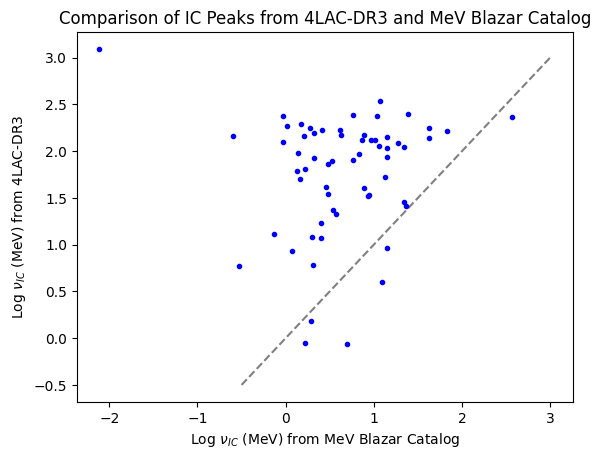

In [18]:
print(len(Matched_Blazar_Fit_FSRQ_IC_peak))
print(len(Matched_Blazar_Fit_FSRQ_names))

LAC_IC_peaks = []
LAC_IC_peaks_err = []
MeV_Fit_IC_peaks = []
MeV_Fit_IC_peaks_err = []
MeV_and_LAC_names = []

for i in range(len(Matched_Blazar_Fit_FSRQ_names)):
    LAC_mask = (Fermi_LAC_DR3['ASSOC1'] == Matched_Blazar_Fit_FSRQ_names[i])
    LAC_entry = Fermi_LAC_DR3[LAC_mask]
    LAC_entry_IC_peak = LAC_entry['HE_EPeak'].tolist()
    LAC_entry_IC_peak_err = LAC_entry['Unc_HE_EPeak'].tolist()
    if LAC_entry_IC_peak != [] and LAC_entry_IC_peak != [None]:
        LAC_IC_peaks.append(np.log10(LAC_entry_IC_peak[0]))
        MeV_Fit_IC_peaks.append((Matched_Blazar_Fit_FSRQ_IC_peak_log[i]))
        LAC_IC_peaks_err.append(abs(np.log10(LAC_entry_IC_peak_err[0])))
        MeV_Fit_IC_peaks_err.append(abs(np.log10(Matched_Blazar_Fit_FSRQ_IC_peak_err[i])))
        MeV_and_LAC_names.append(Matched_Blazar_Fit_FSRQ_names[i])

x = np.linspace(-0.5, 3, 100)
y = x

print(LAC_IC_peaks)
print(len(LAC_IC_peaks))
print(MeV_Fit_IC_peaks)
print(len(MeV_Fit_IC_peaks))

plt.errorbar(MeV_Fit_IC_peaks, LAC_IC_peaks, fmt='o', markersize=3, color='blue')
plt.plot(x, y, linestyle='--', color='grey', label='y = x')
plt.ylabel(r'Log $\nu_{IC}$ (MeV) from 4LAC-DR3')
plt.xlabel(r'Log $\nu_{IC}$ (MeV) from MeV Blazar Catalog')
plt.title('Comparison of IC Peaks from 4LAC-DR3 and MeV Blazar Catalog')
plt.savefig(outdir + 'MeV_and_LAC_IC_peaks_comparison.png')


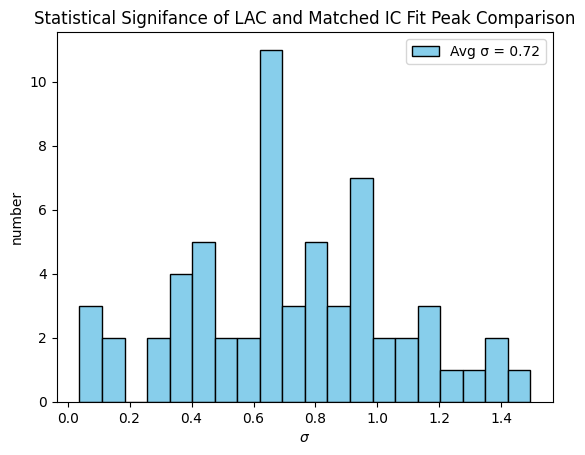

In [19]:
Sigma_LAC_Matched_Fit = []
for i in range(len(LAC_IC_peaks)):
    sigma_diff = sigma_difference(LAC_IC_peaks[i], LAC_IC_peaks_err[i], MeV_Fit_IC_peaks[i], MeV_Fit_IC_peaks_err[i])
    #print(f'{MeV_and_LAC_names[i]}: {sigma_diff}\u03C3')
    Sigma_LAC_Matched_Fit.append(sigma_diff)

avg_sigma_LAC_matched = np.mean(Sigma_LAC_Matched_Fit)

num_bins = 20
fig, ax = plt.subplots()
n, bins, patches = ax.hist(Sigma_LAC_Matched_Fit, num_bins, color = 'skyblue', edgecolor = 'black', label =f'Avg σ = {avg_sigma_LAC_matched:.2f}')
plt.legend(loc = 'upper right')
plt.title('Statistical Signifance of LAC and Matched IC Fit Peak Comparison')
plt.xlabel(r'$\sigma$')
plt.ylabel('number')
plt.savefig(outdir + 'LAC_and_matched_IC_peak_sigma_histogram.png')

In [20]:
Fermi_LAC_DR3_FSRQ, Fermi_LAC_DR3_BLL, Fermi_LAC_DR3_BCU = mask_catalog_by_class(Fermi_LAC_DR3, 'CLASS')
Fermi_LAC_DR3_all = [Fermi_LAC_DR3_FSRQ, Fermi_LAC_DR3_BLL, Fermi_LAC_DR3_BCU]

65
46
14


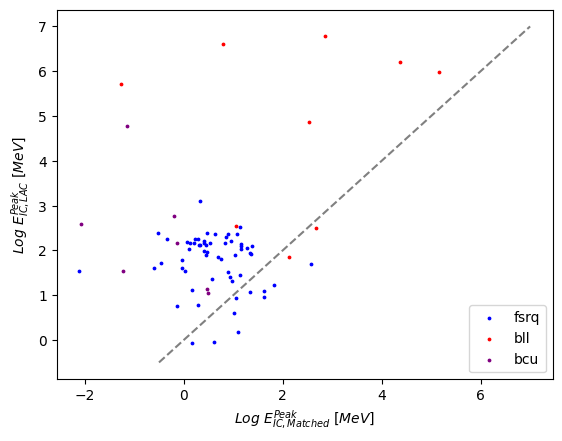

In [21]:
colors = ['blue', 'red', 'purple']
labels = ['fsrq', 'bll', 'bcu']

for i in range(len(Matched_Blazar_Fit_Catalogs_by_class)):
    Match_name = Matched_Blazar_Fit_Catalogs_by_class[i]['Name'].tolist()
    Match_peak = Matched_Blazar_Fit_Catalogs_by_class[i]['IC_Peak_Energy'].tolist()
    Source_mask = [x in Match_name for x in Fermi_LAC_DR3_all[i]['ASSOC1'].tolist()]
    LAC_peak = Fermi_LAC_DR3_all[i][Source_mask]['HE_EPeak'].tolist()

    LAC_known_peak = []
    Match_known_peak = []

    print(len(LAC_peak))
    for x in range(len(LAC_peak)):
        if LAC_peak[x] != None and Match_peak[x] != 'None':
            if np.log10(float(Match_peak[x])) >= -8:
                LAC_known_peak.append(np.log10(LAC_peak[x]))
                Match_known_peak.append(np.log10(float(Match_peak[x])))

    
    plt.scatter(Match_known_peak, LAC_known_peak, s = 3, color = colors[i], label = labels[i])
    
    plt.ylabel(r'$Log$ $E^{Peak}_{IC, LAC}$ $[MeV]$')
    plt.xlabel(r'$Log$ $E^{Peak}_{IC, Matched}$ $[MeV]$')
    #plt.title('LAC and Matched Fit Peak Comparison')
    plt.legend(loc = 'lower right')

x = np.linspace(-0.5, 7, 100)
y = x

plt.plot(x, y, linestyle='--', color='grey', label='y = x')

plt.savefig(outdir + 'LAC_Match_Peak_Comparison.png', bbox_inches='tight')


In [22]:
Matched_Fits_Fermi_only = Table.read(outdir + 'Blazar_Fitter_out/Matched_Fits_Fermi_Only/Matched_Fits_Fermi_only_results.fits')
Matched_Fits_Fermi_only

Name,Class,Alpha,Alpha_Err,Beta,Beta_Err,IC_Peak_Energy,IC_Peak_Energy_Err,IC_Peak_Energy_Flux,Chi2
bytes23,bytes4,float64,float64,float64,float64,bytes32,bytes32,bytes32,float64
1ES 0033+595,bll,1.3466001915746404,0.10211355641523912,0.044116280410268514,0.010099747447985512,116311.10562888706,238753.5593057656,5.3610025108891805e-06,1.0888439677466475e-06
RX J0115.7+2519,bll,1.7633283461547589,0.10179933355448458,0.022382486198617605,0.01115776846388813,13982.750264604801,48674.76774067196,1.7667646288951383e-06,1.0285216553837968e-06
1ES 0120+340,bll,0.6270192895389567,0.5393180396758113,0.09509038472577853,0.04786003313824749,96562.1618986463,445074.44224531,6.49583548872735e-07,0.00011942424768838364
B3 0133+388,bll,0.6044823704313823,0.07739026200137798,0.13030532900243913,0.007943750071112367,14963.891735899067,6603.610154892713,7.096052953203117e-06,1.7034806890703482e-06
TXS 0134+579,bll,1.9252627322175628,0.11925779112241762,0.0017183514111265225,0.013027495375158196,196787527063.94534,33155404816170.676,2.725938637766945e-06,5.429383105801069e-07
B2 0135+291,bcu,2.15958848772616,0.5024394745872767,0.11265286037974212,0.1326999056876974,34.822957369310295,82.91391503016747,1.0187498050917208e-06,1.1005484115082044e-06
PKS 0142-278,fsrq,2.0897604847254025,0.16651728646734282,0.11581543733223808,0.03442184788654436,47.994258813033625,34.94262356191428,2.4031361259535533e-06,7.523127185197263e-08
PMN J0151-3605,bcu,2.1402845703428586,0.3261644007612928,0.04626971160178729,0.053454899529871605,15.52812252577764,61.11463612081778,6.350216387267179e-07,1.0055701204617134e-07
1RXS J015658.6-530208,bll,1.115889127239285,0.22509998972396,0.07096474014651233,0.024808514495505,35875.971983246505,96649.91616106778,8.382583506002026e-07,2.771338408573783e-07


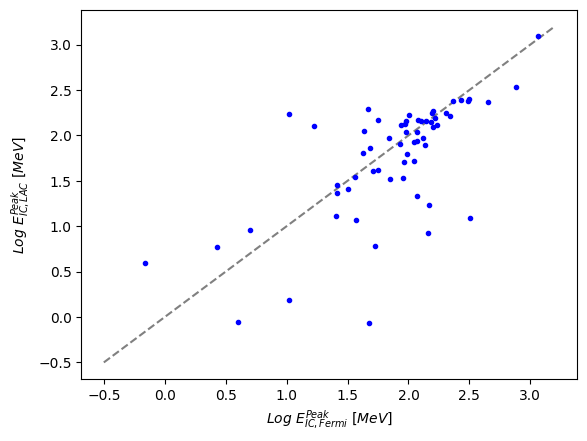

In [23]:
Matched_Fits_Fermi_only = Table.read(outdir + 'Blazar_Fitter_out/Matched_Fits_Fermi_Only/Matched_Fits_Fermi_only_results.fits')
name_comp_mask = [x in MeV_and_LAC_names for x in Matched_Fits_Fermi_only['Name'].tolist()]
Matched_Fits_Fermi_only_masked = Matched_Fits_Fermi_only[name_comp_mask]
Fermi_Only_Fit_IC_peaks = Matched_Fits_Fermi_only_masked['IC_Peak_Energy'].tolist()
Fermi_Only_Fit_IC_peaks_err = Matched_Fits_Fermi_only_masked['IC_Peak_Energy_Err'].tolist()
Fermi_Only_Fit_IC_peaks_log = [math.log10(float(i)) for i in Fermi_Only_Fit_IC_peaks]
Fermi_Only_Fit_IC_peaks_err_log = [math.log10(float(i)) for i in Fermi_Only_Fit_IC_peaks_err]

x = np.linspace(-0.5, 3.2, 100)
y = x
#print(len(Fermi_MeV_Fit_IC_peaks), len(LAC_and_MeV_Cat_IC_peaks))

plt.errorbar(Fermi_Only_Fit_IC_peaks_log, LAC_IC_peaks, fmt='o', markersize=3, color='blue')
plt.plot(x, y, linestyle='--', color='grey', label='y = x')
plt.ylabel(r'$Log$ $E^{Peak}_{IC, LAC}$ $[MeV]$')
plt.xlabel(r'$Log$ $E^{Peak}_{IC, Fermi}$ $[MeV]$')
plt.savefig(outdir + 'Fermi_Only_Fit_LAC_comparison.png', bbox_inches='tight')

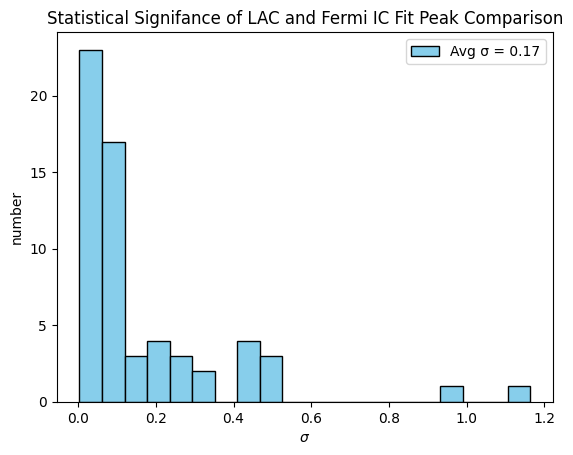

In [24]:
Sigma_LAC_Fermi_Fit = []
for i in range(len(MeV_and_LAC_names)):
    sigma_diff = sigma_difference(LAC_IC_peaks[i], LAC_IC_peaks_err[i], Fermi_Only_Fit_IC_peaks_log[i], Fermi_Only_Fit_IC_peaks_err_log[i])
    #print(f'{Fermi_MeV_and_LAC_names[i]}: {sigma_diff}\u03C3')
    Sigma_LAC_Fermi_Fit.append(sigma_diff)

avg_sigma_LAC_Fermi_fit = np.mean(Sigma_LAC_Fermi_Fit)
    
num_bins = 20
fig, ax = plt.subplots()
n, bins, patches = ax.hist(Sigma_LAC_Fermi_Fit, num_bins, label =f'Avg σ = {avg_sigma_LAC_Fermi_fit:.2f}', color = 'skyblue', edgecolor = 'black')
plt.title('Statistical Signifance of LAC and Fermi IC Fit Peak Comparison')
plt.xlabel(r'$\sigma$')
plt.ylabel('number')
plt.legend(loc = 'upper right')
plt.savefig(outdir + 'LAC_and_Fermi_IC_peak_sigma_histogram.png')